# 10. 전처리 — data.csv × photos 매칭

**목적**: `data.csv`의 타임스탬프를 `YYYYMMDDhhmmss.jpg` 형식으로 변환해 `photos/` 폴더의 이미지와 매칭하고,
성장 일수(`delta_days`) 레이블을 생성해 학습용 CSV / parquet 파일을 구성합니다.

**출력**:
- `dataset/collector/collector_dataset.csv` — 모델 학습용 메인 CSV
- `dataset/collector/{train,val,test}.parquet` — 분할별 parquet
- `dataset/collector/sensor_norm_stats.parquet` — 정규화 통계

In [16]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path('/content')
    CSV_PATH   = ROOT / 'data.csv'
    PHOTOS_DIR = ROOT / 'photos'
    OUT_DIR    = ROOT / 'dataset' / 'collector'
else:
    ROOT       = Path(os.getcwd()).parent
    CSV_PATH   = ROOT / 'data.csv'
    PHOTOS_DIR = ROOT / 'photos'
    OUT_DIR    = ROOT / 'dataset' / 'collector'

print(f'ROOT      : {ROOT}')
print(f'CSV_PATH  : {CSV_PATH}')
print(f'PHOTOS_DIR: {PHOTOS_DIR}')
print(f'OUT_DIR   : {OUT_DIR}')

ROOT      : /Users/mainframe/Workspace/Graduate
CSV_PATH  : /Users/mainframe/Workspace/Graduate/data.csv
PHOTOS_DIR: /Users/mainframe/Workspace/Graduate/photos
OUT_DIR   : /Users/mainframe/Workspace/Graduate/dataset/collector


## 1. CSV 로드 및 타임스탬프 변환

In [17]:
df = pd.read_csv(CSV_PATH)
print(f'원본 행 수: {len(df)}')
df.head(3)

원본 행 수: 1962


,time,device_id,air_temperature,air_humidity,light,soil_temperature,soil_moisture,soil_ph,soil_ec,soil_nitrogen,soil_phosphorus,soil_potassium
0,2026-04-20 21:50:54.694088,collector_001,25.3,25.4,3192.0,23.1,17.7,7.2,175.0,7.0,12.0,28.0
1,2026-04-20 21:51:14.699595,collector_001,25.3,25.5,3297.0,23.1,17.7,7.2,175.0,7.0,12.0,28.0
2,2026-04-20 21:51:57.713562,collector_001,25.3,25.4,3235.0,23.1,17.7,7.2,175.0,7.0,12.0,28.0


In [18]:
# 소수점 이하 제거 후 datetime 파싱
df['time'] = df['time'].str.split('.').str[0]
df['datetime'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')

# 이미지 파일명 생성: YYYYMMDDhhmmss.jpg
df['image_filename'] = df['datetime'].dt.strftime('%Y%m%d%H%M%S') + '.jpg'
df['image_path']     = df['image_filename'].apply(lambda f: str(PHOTOS_DIR / f))

df[['time', 'datetime', 'image_filename']].head(5)

,time,datetime,image_filename
0,2026-04-20 21:50:54,2026-04-20 21:50:54,20260420215054.jpg
1,2026-04-20 21:51:14,2026-04-20 21:51:14,20260420215114.jpg
2,2026-04-20 21:51:57,2026-04-20 21:51:57,20260420215157.jpg
3,2026-04-20 21:54:49,2026-04-20 21:54:49,20260420215449.jpg
4,2026-04-20 22:01:26,2026-04-20 22:01:26,20260420220126.jpg


## 2. 이미지 존재 여부 확인 (매칭)

In [19]:
df['image_exists'] = df['image_path'].apply(lambda p: Path(p).exists())

matched   = df['image_exists'].sum()
unmatched = (~df['image_exists']).sum()
print(f'매칭 성공: {matched} / {len(df)}  ({matched/len(df)*100:.1f}%)')
print(f'매칭 실패: {unmatched}')

if unmatched > 0:
    print('\n매칭 실패 행:')
    display(df[~df['image_exists']][['time', 'image_filename']])

매칭 성공: 1961 / 1962  (99.9%)
매칭 실패: 1

매칭 실패 행:


,time,image_filename
0,2026-04-20 21:50:54,20260420215054.jpg


In [20]:
# 매칭된 행만 유지
df_matched = df[df['image_exists']].reset_index(drop=True)
print(f'최종 사용 행 수: {len(df_matched)}')

최종 사용 행 수: 1961


## 3. delta_days 생성 (성장 일수 레이블)

데이터셋 내 **첫 번째 타임스탬프**를 기준(day 0)으로,
각 행이 몇 일이 경과했는지를 연속값 `delta_days`로 계산합니다.

> **주의**: `time`, `datetime` 컬럼은 레이블 생성 전용입니다.  
> 모델의 입력(X)에는 절대 포함하지 않습니다.

In [21]:
# 첫 번째 타임스탬프 = 전체 데이터셋의 day 0
T0 = df_matched['datetime'].min()
print(f'기준 시각 (day 0): {T0}')

df_matched['delta_days'] = (
    (df_matched['datetime'] - T0).dt.total_seconds() / 86400
).round(6)

print(f'delta_days 범위: {df_matched["delta_days"].min():.3f} ~ {df_matched["delta_days"].max():.3f} 일')
df_matched[['time', 'delta_days']].head(8)

기준 시각 (day 0): 2026-04-20 21:51:14
delta_days 범위: 0.000 ~ 6.868 일


,time,delta_days
0,2026-04-20 21:51:14,0.000000
1,2026-04-20 21:51:57,0.000498
2,2026-04-20 21:54:49,0.002488
3,2026-04-20 22:01:26,0.007083
4,2026-04-20 22:06:28,0.010579
5,2026-04-20 22:11:30,0.014074
6,2026-04-20 22:16:32,0.017569
7,2026-04-20 22:21:33,0.021053


/var/folders/6_/3w3d4c8j4wxg42qp28pdslsr0000gn/T/ipykernel_95191/4126179840.py:13: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6_/3w3d4c8j4wxg42qp28pdslsr0000gn/T/ipykernel_95191/4126179840.py:13: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6_/3w3d4c8j4wxg42qp28pdslsr0000gn/T/ipykernel_95191/4126179840.py:13: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6_/3w3d4c8j4wxg42qp28pdslsr0000gn/T/ipykernel_95191/4126179840.py:13: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6_/3w3d4c8j4wxg42qp28pdslsr0000gn/T/ipykernel_95191/4126179840.py:13: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13

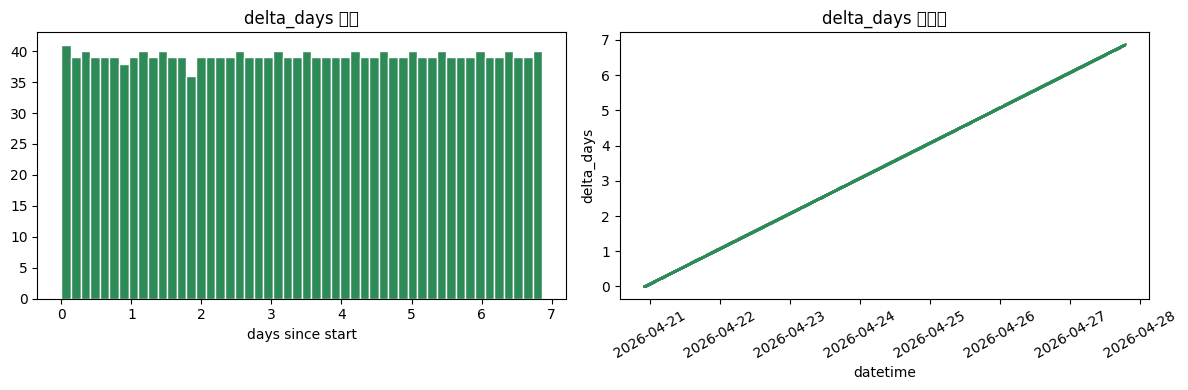

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_matched['delta_days'], bins=50, color='seagreen', edgecolor='white')
axes[0].set_title('delta_days 분포')
axes[0].set_xlabel('days since start')

axes[1].plot(df_matched['datetime'], df_matched['delta_days'], '.', markersize=2, color='seagreen')
axes[1].set_title('delta_days 시계열')
axes[1].set_xlabel('datetime')
axes[1].set_ylabel('delta_days')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. 센서 데이터 탐색

In [23]:
SENSOR_COLS = [
    'air_temperature', 'air_humidity', 'light',
    'soil_temperature', 'soil_moisture', 'soil_ph',
    'soil_ec', 'soil_nitrogen', 'soil_phosphorus', 'soil_potassium'
]

df_matched[SENSOR_COLS].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
air_temperature,1961.0,21.787,1.015,19.1,21.0,21.7,22.5,25.8
air_humidity,1961.0,27.676,4.732,14.7,24.1,27.7,31.8,39.1
light,1961.0,1143.641,1239.319,0.0,1.0,688.0,1982.0,4954.0
soil_temperature,1961.0,19.221,1.216,16.7,18.4,19.2,20.2,23.1
soil_moisture,1961.0,20.437,1.383,17.6,19.3,20.1,21.6,22.9
soil_ph,1961.0,7.060,0.076,6.9,7.0,7.1,7.1,7.3
soil_ec,1961.0,287.620,59.562,175.0,239.0,279.0,345.0,383.0
soil_nitrogen,1961.0,13.106,3.016,7.0,11.0,13.0,16.0,18.0
soil_phosphorus,1961.0,19.746,4.141,12.0,16.0,19.0,24.0,26.0
soil_potassium,1961.0,46.255,9.534,28.0,38.0,45.0,55.0,62.0


/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49468 (\N{HANGUL SYLLABLE SEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core

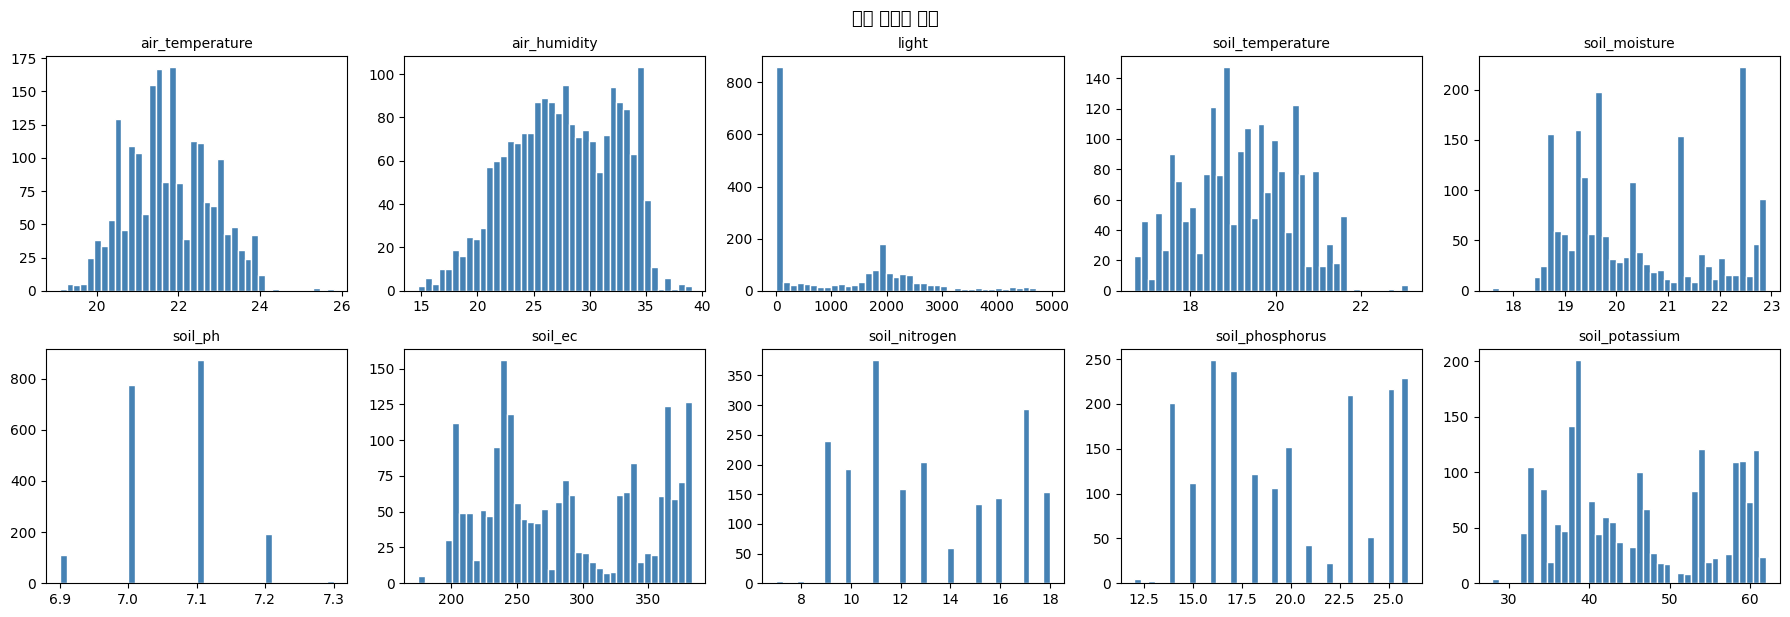

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()
for i, col in enumerate(SENSOR_COLS):
    axes[i].hist(df_matched[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.suptitle('센서 데이터 분포', y=1.02, fontsize=13)
plt.show()

In [25]:
missing = df_matched[SENSOR_COLS].isna().sum()
print('컬럼별 결측값:')
print(missing[missing > 0] if missing.any() else '결측값 없음')

컬럼별 결측값:
결측값 없음


## 5. 시간 기반 Train / Val / Test 분할

시계열 데이터이므로 랜덤 셔플 없이 시간 순 분할합니다.

In [26]:
TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15

n = len(df_matched)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

df_train = df_matched.iloc[:n_train].copy()
df_val   = df_matched.iloc[n_train:n_train + n_val].copy()
df_test  = df_matched.iloc[n_train + n_val:].copy()

for split, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(f'{split:5s}: {len(d):4d} 행  '
          f'delta_days [{d["delta_days"].min():.2f} ~ {d["delta_days"].max():.2f}]')

train: 1372 행  delta_days [0.00 ~ 4.81]
val  :  294 행  delta_days [4.81 ~ 5.84]
test :  295 행  delta_days [5.84 ~ 6.87]


## 6. 센서 정규화 (train 기준 통계)

In [27]:
sensor_mean = df_train[SENSOR_COLS].mean()
sensor_std  = df_train[SENSOR_COLS].std().replace(0, 1)

for split_df in [df_train, df_val, df_test]:
    for col in SENSOR_COLS:
        split_df[f'{col}_norm'] = (split_df[col] - sensor_mean[col]) / sensor_std[col]

norm_stats = pd.DataFrame({'mean': sensor_mean, 'std': sensor_std})
print('정규화 통계 (train 기준):')
display(norm_stats.round(4))

정규화 통계 (train 기준):


,mean,std
air_temperature,21.6756,1.0654
air_humidity,27.7701,5.0430
light,1190.2988,1263.4863
soil_temperature,19.0006,1.2505
soil_moisture,20.9916,1.2745
soil_ph,7.0829,0.0675
soil_ec,312.4832,52.7769
soil_nitrogen,14.3528,2.6865
soil_phosphorus,21.4723,3.6789
soil_potassium,50.2369,8.4405


## 7. 이미지 샘플 확인

/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45924 (\N{HANGUL SYLLABLE DEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mainframe/Workspace/Graduate/.venv/lib/python3.13/site-packages/IPyth

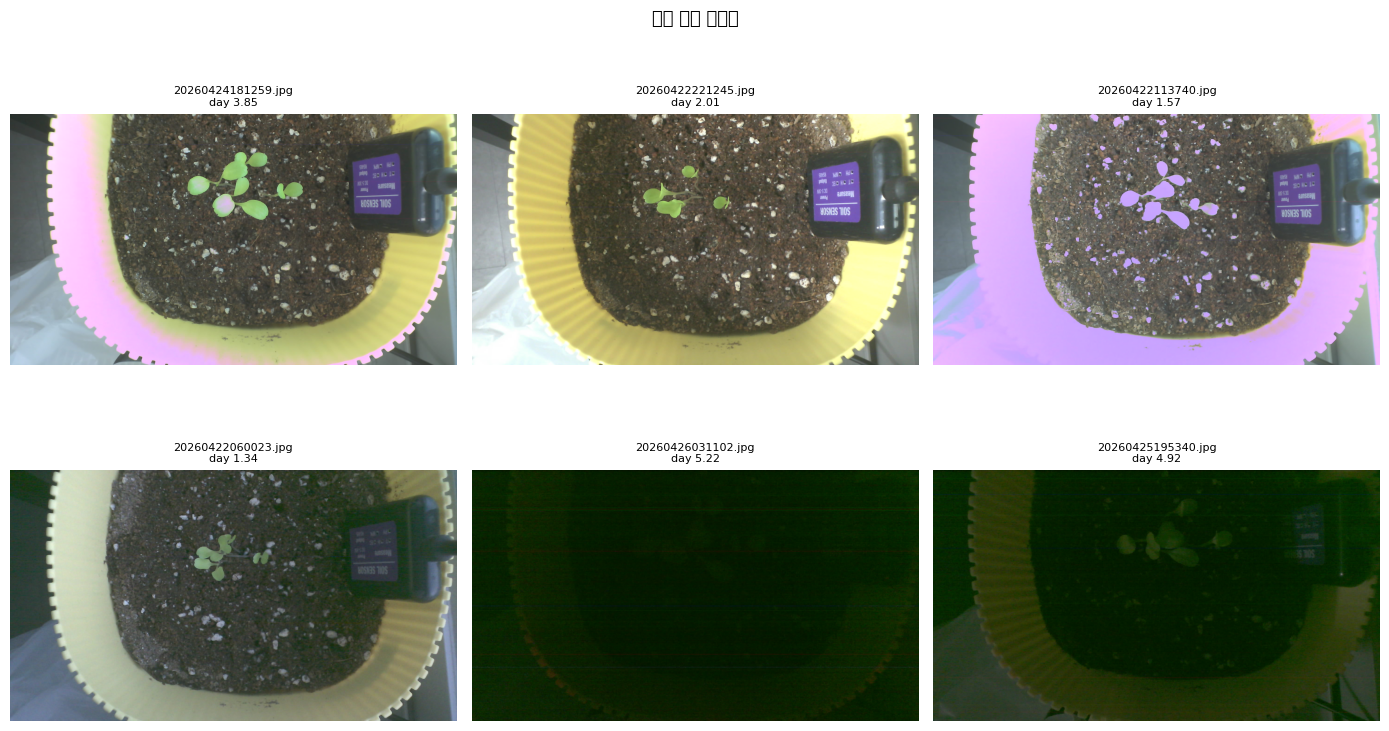

In [28]:
samples = df_matched.sample(6, random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, (_, row) in zip(axes, samples.iterrows()):
    img = mpimg.imread(row['image_path'])
    ax.imshow(img)
    ax.set_title(f"{row['image_filename']}\nday {row['delta_days']:.2f}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.suptitle('랜덤 샘플 이미지', y=1.01, fontsize=13)
plt.show()

## 8. 저장

### 8-A. 모델 학습용 CSV (`collector_dataset.csv`)

- `time`, `datetime` 등 시간 관련 컬럼은 **제외**합니다.
- `image_filename` / `image_path` 는 이미지 로드 경로용으로만 포함합니다.
- 모델 X 입력: `SENSOR_COLS` (10개) + 이미지
- 모델 Y 레이블: `delta_days`

In [29]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_COLS = SENSOR_COLS + ['image_filename', 'image_path', 'delta_days', 'split']

# split 컬럼 추가
df_train = df_train.copy(); df_train['split'] = 'train'
df_val   = df_val.copy();   df_val['split']   = 'val'
df_test  = df_test.copy();  df_test['split']  = 'test'

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

csv_path = OUT_DIR / 'collector_dataset.csv'
df_all[SAVE_COLS].to_csv(csv_path, index=False)
print(f'CSV 저장: {csv_path}  ({len(df_all)} 행)')
print(f'컬럼: {SAVE_COLS}')

CSV 저장: /Users/mainframe/Workspace/Graduate/dataset/collector/collector_dataset.csv  (1961 행)
컬럼: ['air_temperature', 'air_humidity', 'light', 'soil_temperature', 'soil_moisture', 'soil_ph', 'soil_ec', 'soil_nitrogen', 'soil_phosphorus', 'soil_potassium', 'image_filename', 'image_path', 'delta_days', 'split']


### 8-B. 분할별 Parquet 및 정규화 통계

In [30]:
# 정규화 통계 저장 (inference 시 재사용)
norm_stats.to_parquet(OUT_DIR / 'sensor_norm_stats.parquet')

# 분할별 parquet (모든 컬럼 포함, 편의용)
for split, split_df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    out_path = OUT_DIR / f'{split}.parquet'
    split_df[SAVE_COLS].to_parquet(out_path, index=False)
    print(f'저장: {out_path}  ({len(split_df)} 행)')

저장: /Users/mainframe/Workspace/Graduate/dataset/collector/train.parquet  (1372 행)
저장: /Users/mainframe/Workspace/Graduate/dataset/collector/val.parquet  (294 행)
저장: /Users/mainframe/Workspace/Graduate/dataset/collector/test.parquet  (295 행)


### 8-C. 이미지 디렉터리 구성 (심볼릭 링크)

In [31]:
def link_images(split_df: pd.DataFrame, split_name: str) -> None:
    split_dir = OUT_DIR / split_name / 'photos'
    split_dir.mkdir(parents=True, exist_ok=True)
    ok = 0
    for _, row in split_df.iterrows():
        src = Path(row['image_path'])
        dst = split_dir / row['image_filename']
        if dst.exists() or dst.is_symlink():
            dst.unlink()
        dst.symlink_to(src.resolve())
        ok += 1
    print(f'{split_name:5s}: {ok} 개 링크 → {split_dir}')

for split, split_df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    link_images(split_df, split)

train: 1372 개 링크 → /Users/mainframe/Workspace/Graduate/dataset/collector/train/photos
val  : 294 개 링크 → /Users/mainframe/Workspace/Graduate/dataset/collector/val/photos
test : 295 개 링크 → /Users/mainframe/Workspace/Graduate/dataset/collector/test/photos


## 9. 최종 요약

In [32]:
print('=' * 55)
print('전처리 완료 요약')
print('=' * 55)
print(f'  원본 CSV 행 수      : {len(df)}')
print(f'  이미지 매칭 성공    : {len(df_matched)}  ({len(df_matched)/len(df)*100:.1f}%)')
print(f'  기준 시각 (day 0)   : {T0}')
print(f'  delta_days 범위     : {df_matched["delta_days"].min():.3f} ~ {df_matched["delta_days"].max():.3f} 일')
print()
print(f'  train : {len(df_train):4d} 행  (day {df_train["delta_days"].min():.2f} ~ {df_train["delta_days"].max():.2f})')
print(f'  val   : {len(df_val):4d} 행  (day {df_val["delta_days"].min():.2f} ~ {df_val["delta_days"].max():.2f})')
print(f'  test  : {len(df_test):4d} 행  (day {df_test["delta_days"].min():.2f} ~ {df_test["delta_days"].max():.2f})')
print()
print('모델 입력(X) 컬럼 (10개):')
print(' ', SENSOR_COLS)
print('모델 레이블(Y): delta_days')
print()
print('저장 파일:')
for f in sorted(OUT_DIR.glob('*.parquet')) :
    print(f'  {f.relative_to(ROOT)}')
print(f'  {csv_path.relative_to(ROOT)}')

전처리 완료 요약
  원본 CSV 행 수      : 1962
  이미지 매칭 성공    : 1961  (99.9%)
  기준 시각 (day 0)   : 2026-04-20 21:51:14
  delta_days 범위     : 0.000 ~ 6.868 일

  train : 1372 행  (day 0.00 ~ 4.81)
  val   :  294 행  (day 4.81 ~ 5.84)
  test  :  295 행  (day 5.84 ~ 6.87)

모델 입력(X) 컬럼 (10개):
  ['air_temperature', 'air_humidity', 'light', 'soil_temperature', 'soil_moisture', 'soil_ph', 'soil_ec', 'soil_nitrogen', 'soil_phosphorus', 'soil_potassium']
모델 레이블(Y): delta_days

저장 파일:
  dataset/collector/sensor_norm_stats.parquet
  dataset/collector/test.parquet
  dataset/collector/train.parquet
  dataset/collector/val.parquet
  dataset/collector/collector_dataset.csv
